# Crossmatch: MuSCAT-db targets vs. Ariel target list


Cortesy of Jerome

Which targets already observed by MuSCAT are TESS Objects of Interest
(TOIs), and what is their vetting disposition? This notebook does a spatial
crossmatch between the observed targets in the live `muscat.db` and the TOI
catalog (`data/TOIs.csv`), using `astropy.coordinates` for robust
coordinate handling.

**Environment:** run with the `prose` conda kernel. Data comes straight
from `muscat.db` (via `sqlite3`) and the bundled TOI CSV, so no external
network is needed.

In [1]:
import os
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord, Angle
import astropy.units as u

SEP_ARCSEC = 600.0   # match radius

## 1. MuSCAT targets from the live database

The `targets` table stores RA/Dec in sexagesimal strings (RA in hours, Dec
in degrees). We parse them to decimal degrees with `astropy.Angle` and drop
any rows that fail to parse.

In [2]:
muscat = pd.read_csv('data/targets_muscat-db.csv')
muscat

,object,ra,dec,filters,airmass_min,airmass_max,n_dates,n_frames,instruments,dates,total_exptime_hr,note,is_identified
0,09881,08:47:03.38,+24:57:38.8,z,1.041690,1.061230,1,27,muscat,180316,0.23,NaN,no
1,10115,2:28:32,+36:36:49.1,"g, i, r",1.016000,1.156000,1,639,muscat2,201029,5.33,NaN,no
2,10302,NaN,NaN,"g, i, r, z",1.145000,1.364000,2,908,muscat2,"220504, 220606",7.57,NaN,no
3,105140,19:41:46,+49:52:42.1,"g, i, r, z",1.047000,1.521000,3,1698,muscat2,"200728, 221006, 221016",11.56,NaN,no
4,10mm,12:26:02.48,+34:35:53.0,"g, r, z",1.000000,1.000000,1,3,muscat,150820,0.01,NaN,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2306,ZAndromeda,23:34:43,+48:59:45,"g, i, r, z",1.190000,1.452000,1,2668,muscat2,241102,3.58,NaN,yes
2307,zenith,4:35:39,+28:17:38.1,"g, i, r, z",1.000000,1.000000,1,4,muscat2,221220,0.02,NaN,yes
2308,ZTF09k5sh,2:39:32,+28:18:22,"i, r, z",1.000000,1.000000,1,3,muscat2,200107,0.03,NaN,yes
2309,ZTF21aanfcmk,19:15:51.3123,-07:12:55.108,"g, i, r, z",1.145073,1.146108,1,12,muscat3,210513,0.10,NaN,yes


In [3]:
def to_degrees(ra_strings, dec_strings):
    """Sexagesimal RA (hourangle) / Dec (deg) strings -> decimal degrees."""
    ra_deg, dec_deg = [], []
    for ra_s, dec_s in zip(ra_strings, dec_strings):
        try:
            ra_deg.append(Angle(str(ra_s), unit=u.hourangle).deg)
            dec_deg.append(Angle(str(dec_s), unit=u.deg).deg)
        except Exception:
            ra_deg.append(np.nan)
            dec_deg.append(np.nan)
    return np.array(ra_deg), np.array(dec_deg)

muscat["ra_deg"], muscat["dec_deg"] = to_degrees(muscat["ra"], muscat["dec"])
muscat = muscat.dropna(subset=["ra_deg", "dec_deg"]).reset_index(drop=True)
print(f"{len(muscat)} identified MuSCAT targets with valid coordinates")
muscat.head()

2208 identified MuSCAT targets with valid coordinates


,object,ra,dec,filters,airmass_min,airmass_max,n_dates,n_frames,instruments,dates,total_exptime_hr,note,is_identified,ra_deg,dec_deg
0,09881,08:47:03.38,+24:57:38.8,z,1.04169,1.06123,1,27,muscat,180316,0.23,NaN,no,131.764083,24.960778
1,10115,2:28:32,+36:36:49.1,"g, i, r",1.01600,1.15600,1,639,muscat2,201029,5.33,NaN,no,37.133333,36.613639
2,105140,19:41:46,+49:52:42.1,"g, i, r, z",1.04700,1.52100,3,1698,muscat2,"200728, 221006, 221016",11.56,NaN,no,295.441667,49.878361
3,10mm,12:26:02.48,+34:35:53.0,"g, r, z",1.00000,1.00000,1,3,muscat,150820,0.01,NaN,yes,186.510333,34.598056
4,1156p295,12:01:00,+29:06:14,"g, i, r, z",1.00000,1.10100,1,473,muscat2,260309,5.72,NaN,yes,180.250000,29.103889


## 2. The Ariel catalog

In [4]:
#ariel = pd.read_csv('data/Ariel_MCS_Known_2025-08-18.csv')
ariel = pd.read_csv('data/Ariel_MCS_Known_2026-05-11.csv')
#list(ariel.columns)
ariel['ra_deg'] = ariel['Star RA']
ariel['dec_deg'] = ariel['Star Dec']

ariel = ariel.dropna(subset=["ra_deg", "dec_deg"]).reset_index(drop=True)
print(f"{len(ariel)} Ariel targets with coordinates")

977 Ariel targets with coordinates


## 3. Spatial crossmatch

`search_around_sky` returns every pair of (TOI, MuSCAT) sources within the
match radius. A few arcseconds is enough: MuSCAT pointings are centered on
the catalog position, so a genuine match is essentially coincident.

In [5]:
c_muscat = SkyCoord(muscat["ra_deg"].values * u.deg, muscat["dec_deg"].values * u.deg)
c_ariel = SkyCoord(ariel["ra_deg"].values * u.deg, ariel["dec_deg"].values * u.deg)

i_ariel, i_muscat, d2d, _ = c_muscat.search_around_sky(c_ariel, SEP_ARCSEC * u.arcsec)

print(f"match radius           : {SEP_ARCSEC} arcsec")
print(f"matched pairs          : {len(i_muscat)}")
print(f"distinct MuSCAT targets: {len(set(i_muscat))}")
print(f"distinct TOIs          : {len(set(i_ariel))}")

match radius           : 600.0 arcsec
matched pairs          : 343
distinct MuSCAT targets: 262
distinct TOIs          : 193


## 4. Which MuSCAT targets are Ariel targets

Assemble the matched pairs into a table, sorted by separation.

In [6]:
list(ariel.columns)

['Star Name',
 'Star Mass [Ms]',
 'Star Mass Error Lower [Ms]',
 'Star Mass Error Upper [Ms]',
 'Star Temperature [K]',
 'Star Temperature Error Lower [K]',
 'Star Temperature Error Upper [K]',
 'Star Radius [Rs]',
 'Star Radius Error Lower [Rs]',
 'Star Radius Error Upper [Rs]',
 'Star log(g)',
 'Star log(g) Error Lower',
 'Star log(g) Error Upper',
 'Star Metallicity',
 'Star Metallicity Error Lower',
 'Star Metallicity Error Upper',
 'Metallicity Ratio',
 'Star C/H',
 'Star C/H Error',
 'Star O/H',
 'Star O/H Error',
 'Star N/H',
 'Star N/H Error',
 'Star C/O',
 'Star N/O',
 'Star C/N',
 'Star Age [Gyr]',
 'Star Age Error Lower [Gyr]',
 'Star Age Error Upper [Gyr]',
 'Star Spectral Type',
 'Star Rotational Velocity [km/s]',
 'Star Rotational Velocity Error Lower [km/s]',
 'Star Rotational Velocity Error Upper [km/s]',
 'Star Rotation Period [days]',
 'Star Rotation Period Error Lower [days]',
 'Star Rotation Period Error Upper [days]',
 'Star Distance [pc]',
 'Star Distance Error Lo

In [7]:
matches = pd.DataFrame({
    "muscat_object": muscat["object"].values[i_muscat],
    "instruments": muscat["instruments"].values[i_muscat],
    "n_frames": muscat["n_frames"].values[i_muscat],
    "ariel_name": ariel["Planet Name"].values[i_ariel],
    "period_d": ariel["Planet Period [days]"].values[i_ariel],
    "depth_ppm": ariel["Transit Depth [%]"].values[i_ariel],
    "age":ariel['Star Age [Gyr]'].values[i_ariel],
    "rotation_period":ariel['Star Rotation Period [days]'].values[i_ariel],
    "tess_mag":ariel['Star TESS Mag'].values[i_ariel],
    "sep_arcsec": d2d.arcsec,
})

matches = matches.sort_values("sep_arcsec").reset_index(drop=True)
matches = matches[matches['n_frames']>100]

print(f"{len(matches)} matched pairs "
      f"({matches['muscat_object'].nunique()} distinct MuSCAT targets)\n")

cols = [
    "muscat_object",
    "ariel_name",
    "instruments",
    "n_frames",
    "sep_arcsec",
]

with pd.option_context("display.max_rows", 20, "display.width", 120):
    print(matches[cols].to_string(index=False))

312 matched pairs (235 distinct MuSCAT targets)

                 muscat_object      ariel_name                                 instruments  n_frames  sep_arcsec
                     WASP-158b       WASP-158b                                     muscat3      3296    0.024979
                      EPIC5350          K2-19c                                      muscat       980    0.288135
                      EPIC5350          K2-19b                                      muscat       980    0.288135
                       KELT-9b         KELT-9b                   muscat, muscat3, sinistro     11452    0.546584
                      HD110067       HD110067b                                     muscat3      3594    1.179211
                      HD110067       HD110067d                                     muscat3      3594    1.179211
                      HD110067       HD110067c                                     muscat3      3594    1.179211
                      HD110067       HD110067f 

In [8]:
matches.sort_values('age').head(20)

,muscat_object,instruments,n_frames,ariel_name,period_d,depth_ppm,age,rotation_period,tess_mag,sep_arcsec
212,TOI-6963,sinistro,159,IRAS04125+2902b,8.834978,0.460963,0.0033,11.310,12.81310,206.285689
255,TOI-6963b,muscat,4299,IRAS04125+2902b,8.834978,0.460963,0.0033,11.310,12.81310,249.322123
178,IRAS04125,muscat3,6558,IRAS04125+2902b,8.834978,0.460963,0.0033,11.310,12.81310,176.790768
21,K2-33,muscat3,1847,K2-33b,5.425260,0.193651,0.0093,6.290,12.98950,4.286207
246,HIP 67522,"muscat4, sinistro",4929,HIP67522b,6.959503,0.440218,0.0170,1.418,9.18710,242.996168
247,HIP 67522,"muscat4, sinistro",4929,HIP67522c,14.334892,0.277958,0.0170,1.418,9.18710,242.996168
175,HIP67522,"muscat4, sinistro",24559,HIP67522b,6.959503,0.440218,0.0170,1.418,9.18710,176.090109
174,HIP67522,"muscat4, sinistro",24559,HIP67522c,14.334892,0.277958,0.0170,1.418,9.18710,176.090109
137,V1298Tau,"muscat, muscat2, muscat3, muscat4, sinistro",167009,V1298Taub,24.139600,0.500000,0.0230,2.865,9.49010,126.773455
144,V1298 Tau,"muscat3, sinistro",3604,V1298Taub,24.139600,0.500000,0.0230,2.865,9.49010,135.044829


In [9]:
matches.sort_values('depth_ppm', ascending=False).head(30)

,muscat_object,instruments,n_frames,ariel_name,period_d,depth_ppm,age,rotation_period,tess_mag,sep_arcsec
39,TOI519,"muscat, muscat2, muscat3",3265,TOI-519b,1.265232,9.250861,0.55,NaN,14.43470,12.145548
68,TOI519.01,muscat,430,TOI-519b,1.265232,9.250861,0.55,NaN,14.43470,49.151140
154,TOI-5205,"muscat, muscat2, muscat3, sinistro",6138,TOI-5205b,1.630757,7.216937,NaN,NaN,13.61360,144.474863
99,TOI-5205b,muscat,4124,TOI-5205b,1.630757,7.216937,NaN,NaN,13.61360,82.761991
205,TOI4860,muscat3,1062,TOI-4860b,1.522759,4.885244,NaN,NaN,13.77260,196.332983
74,TOI4201,muscat,753,TOI-4201b,3.581919,3.960130,1.40,17.30,13.50110,57.033184
165,TOI-3884,"muscat3, sinistro",6299,TOI-3884b,4.544586,3.810191,NaN,NaN,12.91130,166.191871
25,WTS-2,muscat3,7129,WTS-2b,1.018707,3.469181,7.00,NaN,14.95600,6.920142
73,TOI3757,muscat,1987,TOI-3757b,3.438753,3.148602,7.10,NaN,13.18580,56.890350
297,WASP80,muscat,2844,WASP-80b,3.067852,2.937000,7.00,NaN,10.36220,328.146297


## 5. Visualize on the sky

All MuSCAT targets and all TOIs, with the matched MuSCAT targets circled.
RA increases to the left, following the usual sky convention.

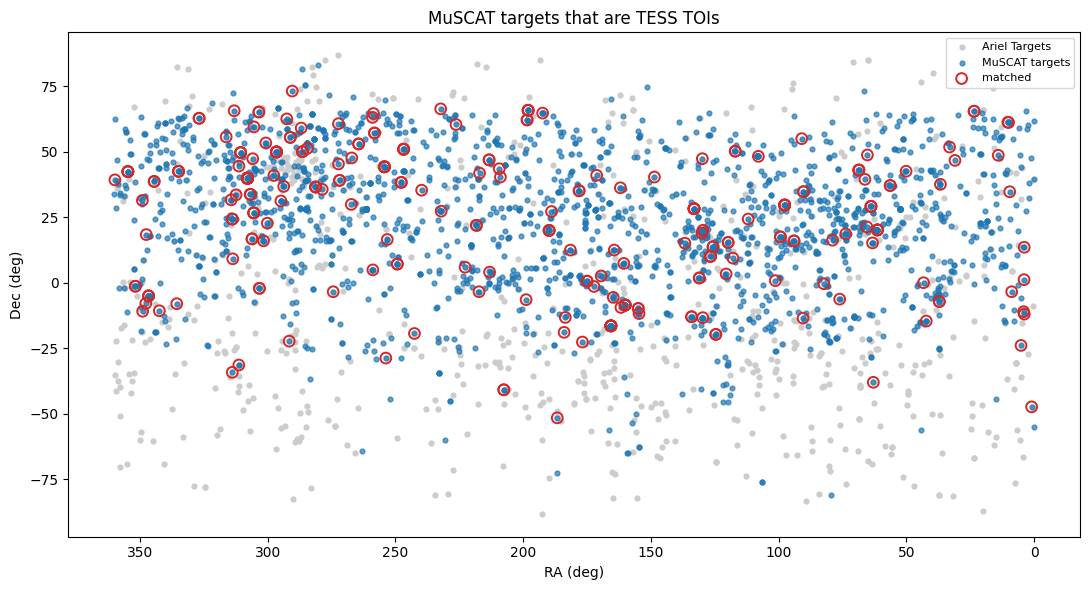

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(ariel["ra_deg"], ariel["dec_deg"], s=12, color="0.8", label="Ariel Targets")
ax.scatter(muscat["ra_deg"], muscat["dec_deg"], s=12, color="C0", alpha=0.7,
           label="MuSCAT targets")
matched_idx = sorted(set(i_muscat))
ax.scatter(muscat["ra_deg"].values[matched_idx], muscat["dec_deg"].values[matched_idx],
           s=60, facecolors="none", edgecolors="C3", linewidths=1.4, label="matched")
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.invert_xaxis()
_ = ax.set_title("MuSCAT targets that are TESS TOIs")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

## 6. Export

Write the matched pairs next to the input catalogs for follow-up.

In [11]:
out = ("data/crossmatch_muscat_ariel.csv")
matches.to_csv(out, index=False)
print(f"wrote {len(matches)} rows to {out}")

wrote 312 rows to data/crossmatch_muscat_ariel.csv


## Summary

- MuSCAT target coordinates come from the live `muscat.db`; the TOI
  positions from the bundled catalog.
- `astropy` `search_around_sky` gives a robust spatial match in a few lines.
- The result flags which observed fields are TOIs and their disposition
  (PC = planet candidate, CP/KP = confirmed/known planet, FP = false
  positive), a useful filter when prioritizing analysis.
- Swap `TOIs.csv` for any catalog with RA/Dec (e.g. confirmed planets in
  `data/nexsci_pscomppars.csv`) to reuse the same workflow.